## <font size=5> <strong>Heart Disease Prediction
 

## Import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#%matplotlib inline

In [2]:
dataset = pd.read_csv(r"D:\MSC. DS\Individual project\Heart-Disease-Prediction-using-Machine-Learning-master\Dataset\heart.csv")

#### Data type

In [3]:
type(dataset)

pandas.core.frame.DataFrame

#### Shape of dataset

In [4]:
dataset.shape

(303, 14)

#### Printing out a few columns

In [5]:
dataset.head(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [6]:
dataset.sample(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
66,51,1,2,100,222,0,1,143,1,1.2,1,0,2,1
65,35,0,0,138,183,0,1,182,0,1.4,2,0,2,1
119,46,0,0,138,243,0,0,152,1,0.0,1,0,2,1
199,65,1,0,110,248,0,0,158,0,0.6,2,2,1,0
62,52,1,3,118,186,0,0,190,0,0.0,1,0,1,1


#### Description

In [7]:
dataset.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [8]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


#### Change the data to Processing

In [9]:
info = [
    "age",
    "1: male, 0: female",
    "chest pain type, 1: typical angina, 2: atypical angina,3: non-anginal pain, 4: asymptomatic",
    "resting blood pressure",
    "serum cholestoral in mg/dl",
    "fasting blood sugar > 120 mg/dl",
    "resting electrocardiographic results (values 0,1,2)",
    "maximum heart rate achieved",
    "exercise induced angina",
    "oldpeak = ST depression induced by exercise relative to rest",
    "the slope of the peak exercise ST segment",
    "number of major vessels (0-3) colored by flourosopy",
    "thal: 0 = normal; 1 = fixed defect; 2 = reversable defect"]


for i in range(len(info)):
    print(dataset.columns[i]+":\t\t\t"+info[i])

age:			age
sex:			1: male, 0: female
cp:			chest pain type, 1: typical angina, 2: atypical angina,3: non-anginal pain, 4: asymptomatic
trestbps:			resting blood pressure
chol:			serum cholestoral in mg/dl
fbs:			fasting blood sugar > 120 mg/dl
restecg:			resting electrocardiographic results (values 0,1,2)
thalach:			maximum heart rate achieved
exang:			exercise induced angina
oldpeak:			oldpeak = ST depression induced by exercise relative to rest
slope:			the slope of the peak exercise ST segment
ca:			number of major vessels (0-3) colored by flourosopy
thal:			thal: 0 = normal; 1 = fixed defect; 2 = reversable defect


#### Analysing the 'target' variable

In [10]:
dataset["target"].describe()

count    303.000000
mean       0.544554
std        0.498835
min        0.000000
25%        0.000000
50%        1.000000
75%        1.000000
max        1.000000
Name: target, dtype: float64

In [11]:
dataset["target"].unique()

array([1, 0], dtype=int64)

### Checking correlation between columns

In [12]:
print(dataset.corr()["target"].abs().sort_values(ascending=False))

target      1.000000
exang       0.436757
cp          0.433798
oldpeak     0.430696
thalach     0.421741
ca          0.391724
slope       0.345877
thal        0.344029
sex         0.280937
age         0.225439
trestbps    0.144931
restecg     0.137230
chol        0.085239
fbs         0.028046
Name: target, dtype: float64


## Exploratory Data Analysis (EDA)

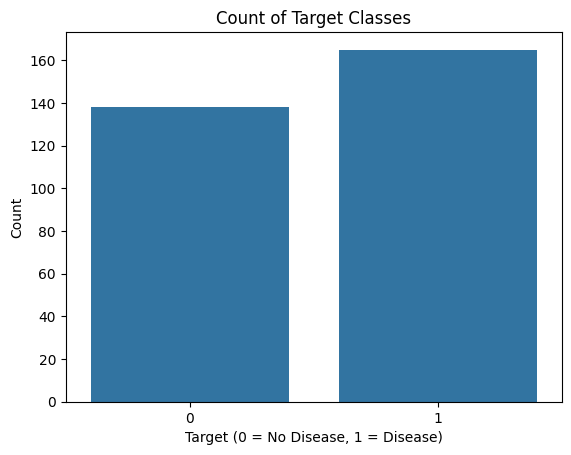

In [13]:
sns.countplot(x="target", data=dataset)
plt.title("Count of Target Classes")
plt.xlabel("Target (0 = No Disease, 1 = Disease)")
plt.ylabel("Count")
plt.show()

In [14]:
target_temp = dataset.target.value_counts()

print("Percentage of patients without heart problems: " + str(round(target_temp[0]*100 / len(dataset), 2)) + "%")
print("Percentage of patients with heart problems: " + str(round(target_temp[1]*100 / len(dataset), 2)) + "%")


Percentage of patients without heart problems: 45.54%
Percentage of patients with heart problems: 54.46%


### Analysing the 'Sex' feature

In [15]:
dataset["sex"].unique()

array([1, 0], dtype=int64)

##### We notice, that as expected, the 'sex' feature has 2 unique features

Text(0, 0.5, 'Count')

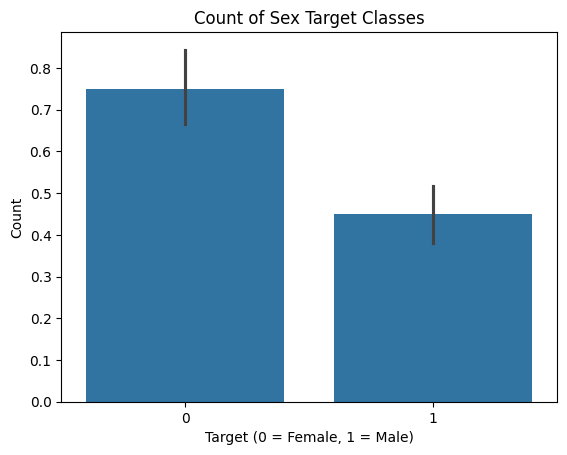

In [16]:
sns.barplot(x=dataset["sex"], y=dataset["target"])
plt.title("Count of Sex Target Classes")
plt.xlabel("Target (0 = Female, 1 = Male)")
plt.ylabel("Count")

##### We notice, that females are more likely to have heart problems than males

### Analysing the 'Chest Pain Type' feature

In [17]:
dataset["cp"].unique()

array([3, 2, 1, 0], dtype=int64)

##### As expected, the CP feature has values from 0 to 3

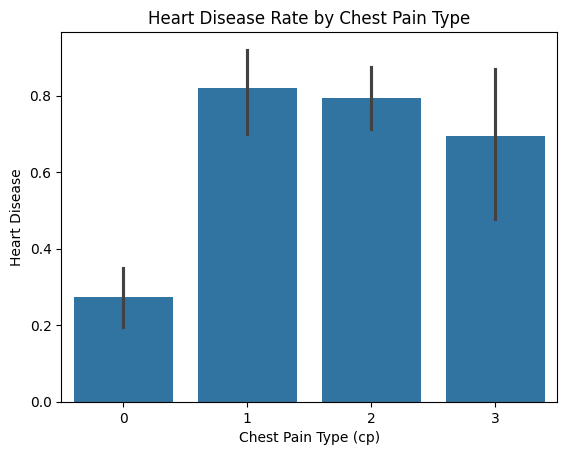

In [18]:
sns.barplot(x="cp", y="target", data=dataset)
plt.title("Heart Disease Rate by Chest Pain Type")
plt.xlabel("Chest Pain Type (cp)")
plt.ylabel("Heart Disease")
plt.show()

##### We notice, that chest pain of '0', i.e. the ones with typical angina are much less likely to have heart problems

### Analysing the FBS feature

In [19]:
dataset["fbs"].describe()

count    303.000000
mean       0.148515
std        0.356198
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        1.000000
Name: fbs, dtype: float64

In [20]:
dataset["fbs"].unique()

array([1, 0], dtype=int64)

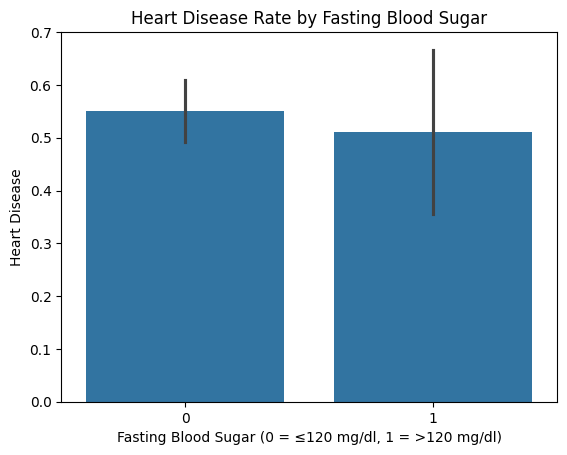

In [21]:
sns.barplot(x="fbs", y="target", data=dataset)
plt.title("Heart Disease Rate by Fasting Blood Sugar")
plt.xlabel("Fasting Blood Sugar (0 = ≤120 mg/dl, 1 = >120 mg/dl)")
plt.ylabel("Heart Disease")
plt.show()

##### Nothing extraordinary here

### Analysing the restecg feature

In [22]:
dataset["restecg"].unique()

array([0, 1, 2], dtype=int64)

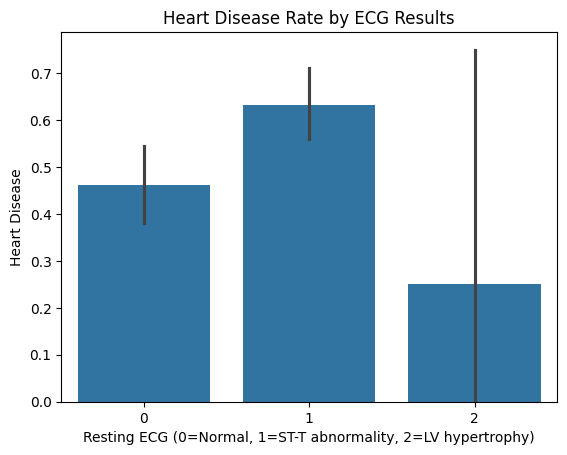

In [23]:
sns.barplot(x="restecg", y="target", data=dataset)
plt.title("Heart Disease Rate by ECG Results")
plt.xlabel("Resting ECG (0=Normal, 1=ST-T abnormality, 2=LV hypertrophy)")
plt.ylabel("Heart Disease")
plt.show()

##### We realize that people with restecg '1' and '0' are much more likely to have a heart disease than with restecg '2'

### Analysing the 'exang' feature

In [24]:
dataset["exang"].unique()

array([0, 1], dtype=int64)

Text(0.5, 1.0, "Analysing the 'exang' feature")

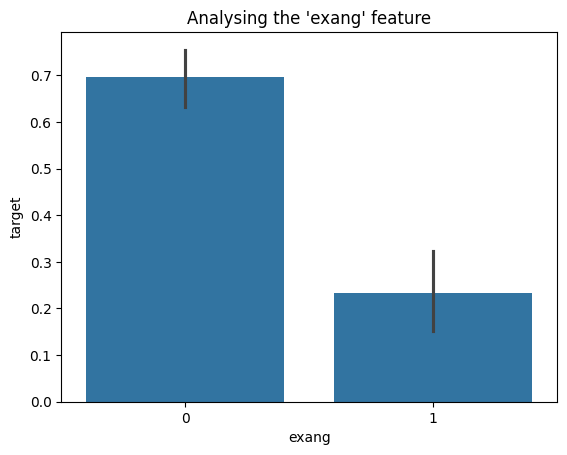

In [25]:
sns.barplot(x="exang",y="target",data= dataset)
plt.title("Analysing the 'exang' feature")

##### People with exang=1 i.e. Exercise induced angina are much less likely to have heart problems

### Analysing the Slope feature

In [26]:
dataset["slope"].unique()

array([0, 2, 1], dtype=int64)

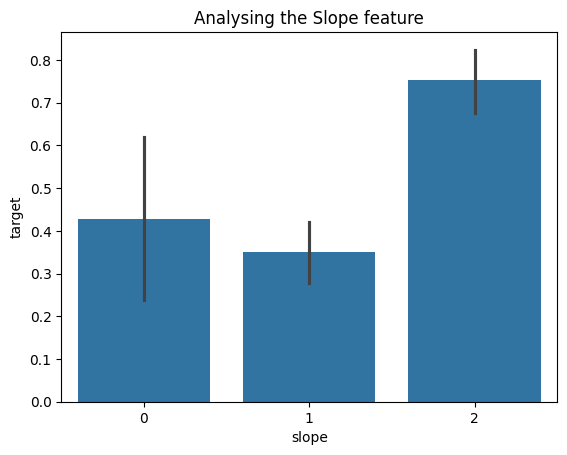

In [27]:
sns.barplot(x="slope", y="target", data=dataset)
plt.title("Analysing the Slope feature")
plt.show()

##### We observe, that Slope '2' causes heart pain much more than Slope '0' and '1'

### Analysing the 'ca' feature

In [28]:
dataset["ca"].unique()

array([0, 2, 1, 3, 4], dtype=int64)

Text(0.5, 1.0, 'Count the ca')

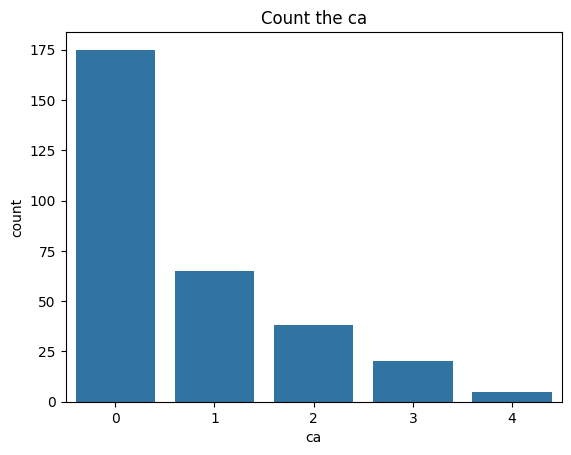

In [29]:
sns.countplot(x="ca",data=dataset)
plt.title("Count the ca")

Text(0.5, 1.0, 'Target the ca')

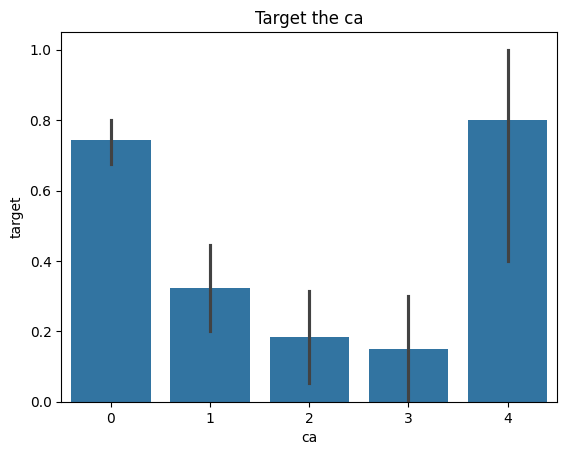

In [30]:
sns.barplot(x="ca", y="target", data = dataset)
plt.title("Target the ca")

##### ca=4 has astonishingly large number of heart patients

### Analysing the 'thal' feature

In [31]:
dataset["thal"].unique()

array([1, 2, 3, 0], dtype=int64)

Text(0.5, 1.0, "Analysing the 'thal' feature")

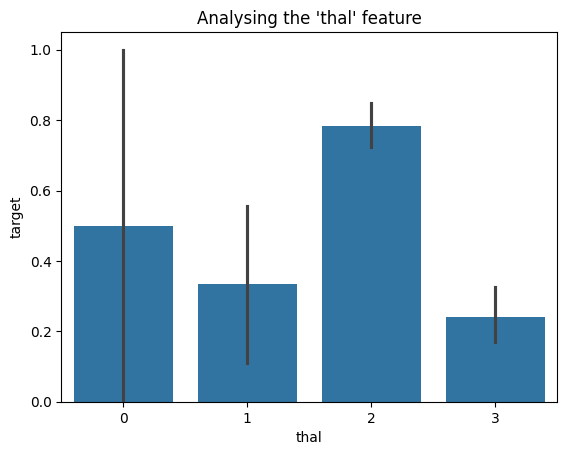

In [32]:
sns.barplot(x="thal",y="target", data = dataset)
plt.title("Analysing the 'thal' feature")

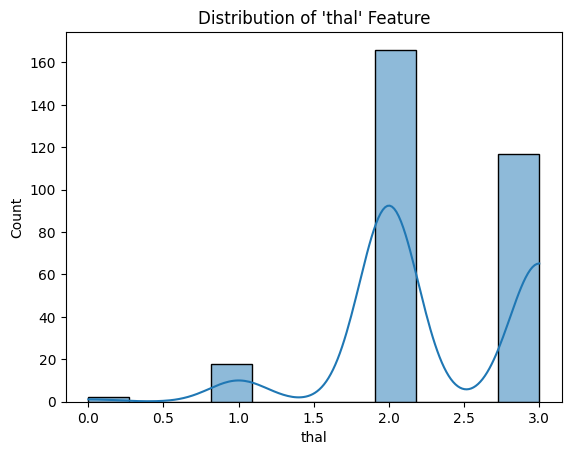

In [33]:
sns.histplot(data=dataset, x="thal", kde=True)
plt.title("Distribution of 'thal' Feature")
plt.show()

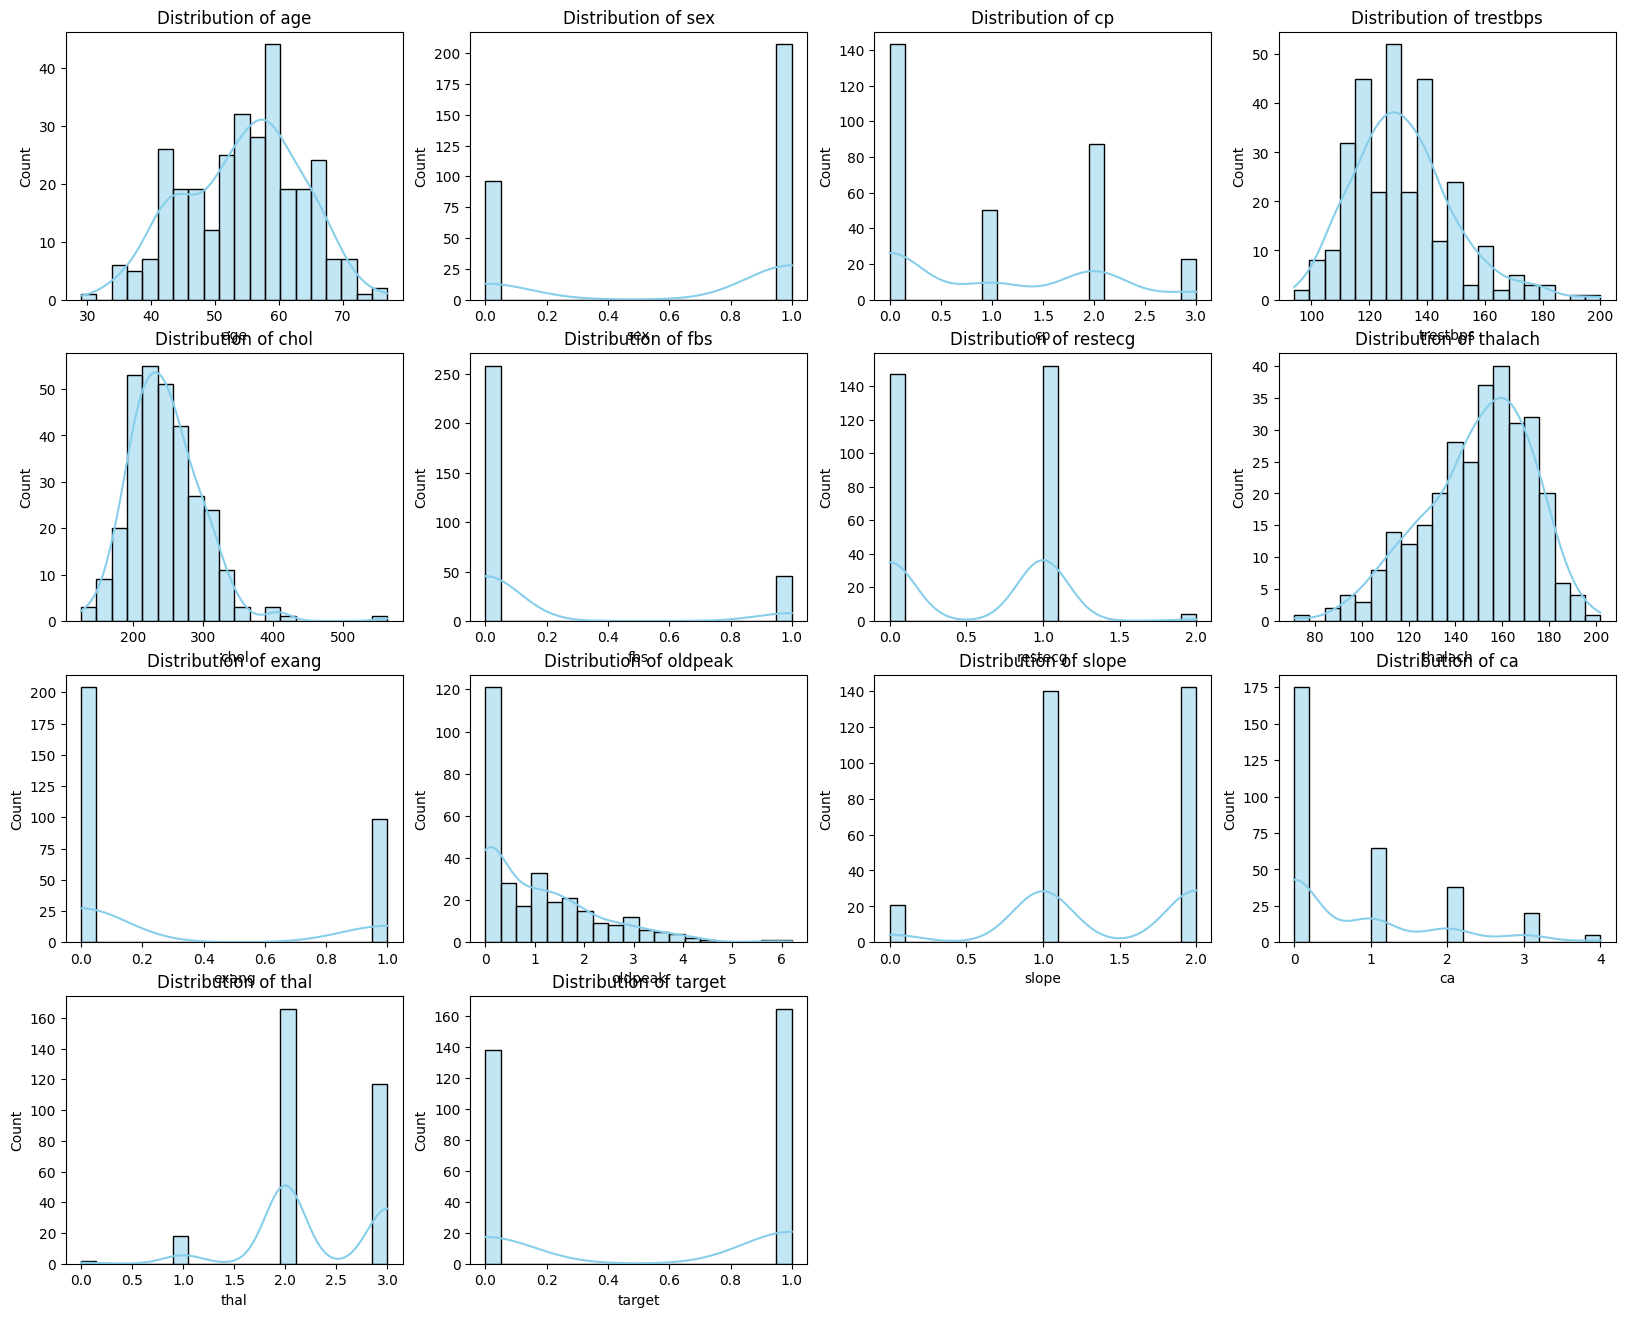

In [34]:
# Select numerical columns
numerical_cols = dataset.select_dtypes(include=['int64', 'float64']).columns

# Set number of rows and columns for subplots
num_cols = 4  # adjust as needed
num_rows = (len(numerical_cols) + num_cols - 1) // num_cols

# Create subplots
plt.figure(figsize=(5*num_cols, 4*num_rows))

for i, col in enumerate(numerical_cols):
    plt.subplot(num_rows, num_cols, i+1)
    sns.histplot(dataset[col], kde=True, bins=20, color='skyblue')
    plt.title(f'Distribution of {col}')

plt.show()

## Train Test split 

In [35]:
# 20% for testing, 80% for training

In [36]:
from sklearn.model_selection import train_test_split

predictors = dataset.drop("target",axis=1)
target = dataset["target"]

X_train,X_test,Y_train,Y_test = train_test_split(predictors,target,test_size=0.20,random_state=0)

In [37]:
X_train.shape

(242, 13)

In [38]:
X_test.shape

(61, 13)

In [39]:
Y_train.shape

(242,)

In [40]:
Y_test.shape

(61,)

## Model Fitting

In [41]:
from sklearn.metrics import accuracy_score

### Logistic Regression

In [42]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()

lr.fit(X_train,Y_train)

Y_pred_lr = lr.predict(X_test)

E:\Python\Python3.12\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [43]:
Y_pred_lr.shape

(61,)

In [44]:
score_lr = round(accuracy_score(Y_pred_lr,Y_test)*100,2)

print("The accuracy score achieved using Logistic Regression is: "+str(score_lr)+" %")

The accuracy score achieved using Logistic Regression is: 85.25 %


### Naive Bayes

In [45]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()

nb.fit(X_train,Y_train)

Y_pred_nb = nb.predict(X_test)

In [46]:
Y_pred_nb.shape

(61,)

In [47]:
score_nb = round(accuracy_score(Y_pred_nb,Y_test)*100,2)

print("The accuracy score achieved using Naive Bayes is: "+str(score_nb)+" %")

The accuracy score achieved using Naive Bayes is: 85.25 %


### SVM

In [48]:
from sklearn import svm

sv = svm.SVC(kernel='linear')

sv.fit(X_train, Y_train)

Y_pred_svm = sv.predict(X_test)

In [49]:
Y_pred_svm.shape

(61,)

In [50]:
score_svm = round(accuracy_score(Y_pred_svm,Y_test)*100,2)

print("The accuracy score achieved using Linear SVM is: "+str(score_svm)+" %")

The accuracy score achieved using Linear SVM is: 81.97 %


### K Nearest Neighbors

In [51]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train,Y_train)
Y_pred_knn=knn.predict(X_test)

In [52]:
Y_pred_knn.shape

(61,)

In [53]:
score_knn = round(accuracy_score(Y_pred_knn,Y_test)*100,2)

print("The accuracy score achieved using KNN is: "+str(score_knn)+" %")

The accuracy score achieved using KNN is: 67.21 %


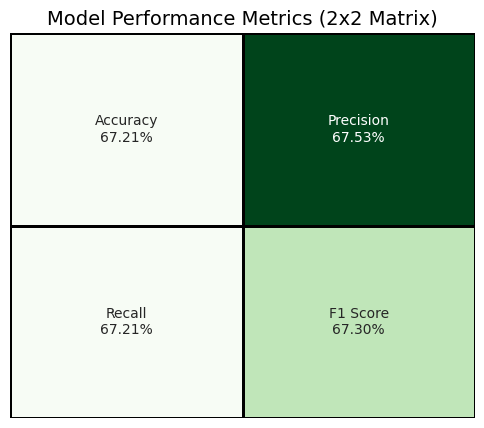

In [71]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. Calculate the 4 metrics
# We use 'weighted' average to handle both binary and multi-class data safely
acc = accuracy_score(Y_test, Y_pred_knn)
prec = precision_score(Y_test, Y_pred_knn, average='weighted')
rec = recall_score(Y_test, Y_pred_knn, average='weighted')
f1 = f1_score(Y_test, Y_pred_knn, average='weighted')

# 2. Prepare the data for the 2x2 matrix
# Row 1: Accuracy, Precision
# Row 2: Recall, F1 Score
metric_values = np.array([[acc, prec], [rec, f1]])
metric_names = np.array([['Accuracy', 'Precision'], ['Recall', 'F1 Score']])

# 3. Create custom labels for the boxes (Name + Score)
# We format them as percentages to match your previous print statement
labels = (np.asarray(["{0}\n{1:.2f}%".format(name, value * 100)
                      for name, value in zip(metric_names.flatten(), metric_values.flatten())])
         ).reshape(2, 2)

# 4. Plot the Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(metric_values, annot=labels, fmt='', cmap='Greens', cbar=False,
            xticklabels=False, yticklabels=False, linewidths=2, linecolor='black')

plt.title('Model Performance Metrics (2x2 Matrix)', fontsize=14)
plt.show()

### Decision Tree

In [55]:
from sklearn.tree import DecisionTreeClassifier

max_accuracy = 0


for x in range(200):
    dt = DecisionTreeClassifier(random_state=x)
    dt.fit(X_train,Y_train)
    Y_pred_dt = dt.predict(X_test)
    current_accuracy = round(accuracy_score(Y_pred_dt,Y_test)*100,2)
    if(current_accuracy>max_accuracy):
        max_accuracy = current_accuracy
        best_x = x
        
#print(max_accuracy)
#print(best_x)


dt = DecisionTreeClassifier(random_state=best_x)
dt.fit(X_train,Y_train)
Y_pred_dt = dt.predict(X_test)

In [56]:
print(Y_pred_dt.shape)

(61,)


In [57]:
score_dt = round(accuracy_score(Y_pred_dt,Y_test)*100,2)

print("The accuracy score achieved using Decision Tree is: "+str(score_dt)+" %")

The accuracy score achieved using Decision Tree is: 81.97 %


### Random Forest

In [58]:
from sklearn.ensemble import RandomForestClassifier

max_accuracy = 0
best_x = 0

In [59]:
for x in range(200):
    rf = RandomForestClassifier(random_state=x)
    rf.fit(X_train,Y_train)
    Y_pred_rf = rf.predict(X_test)
    current_accuracy = round(accuracy_score(Y_pred_rf,Y_test)*100,2)
    if(current_accuracy>max_accuracy):
        max_accuracy = current_accuracy
        best_x = x

In [60]:
rf = RandomForestClassifier(random_state=best_x)
rf.fit(X_train,Y_train)
Y_pred_rf = rf.predict(X_test)

In [61]:
Y_pred_rf.shape

(61,)

In [62]:
score_rf = round(accuracy_score(Y_pred_rf,Y_test)*100,2)

print("The accuracy score achieved using Decision Tree is: "+str(score_rf)+" %")

The accuracy score achieved using Decision Tree is: 88.52 %


### XGBoost

In [63]:
import xgboost as xgb

xgb_model = xgb.XGBClassifier(objective="binary:logistic", random_state=42)
xgb_model.fit(X_train, Y_train)

Y_pred_xgb = xgb_model.predict(X_test)

In [64]:
Y_pred_xgb.shape

(61,)

In [65]:
score_xgb = round(accuracy_score(Y_pred_xgb,Y_test)*100,2)

print("The accuracy score achieved using XGBoost is: "+str(score_xgb)+" %")

The accuracy score achieved using XGBoost is: 83.61 %


### Output final score

In [66]:
scores = [score_lr,score_nb,score_svm,score_knn,score_dt,score_rf,score_xgb]
algorithms = ["Logistic Regression","Naive Bayes","Support Vector Machine","K-Nearest Neighbors","Decision Tree","Random Forest","XGBoost"]    

for i in range(len(algorithms)):
    print("The accuracy score achieved using "+algorithms[i]+" is: "+str(scores[i])+" %")

The accuracy score achieved using Logistic Regression is: 85.25 %
The accuracy score achieved using Naive Bayes is: 85.25 %
The accuracy score achieved using Support Vector Machine is: 81.97 %
The accuracy score achieved using K-Nearest Neighbors is: 67.21 %
The accuracy score achieved using Decision Tree is: 81.97 %
The accuracy score achieved using Random Forest is: 88.52 %
The accuracy score achieved using XGBoost is: 83.61 %


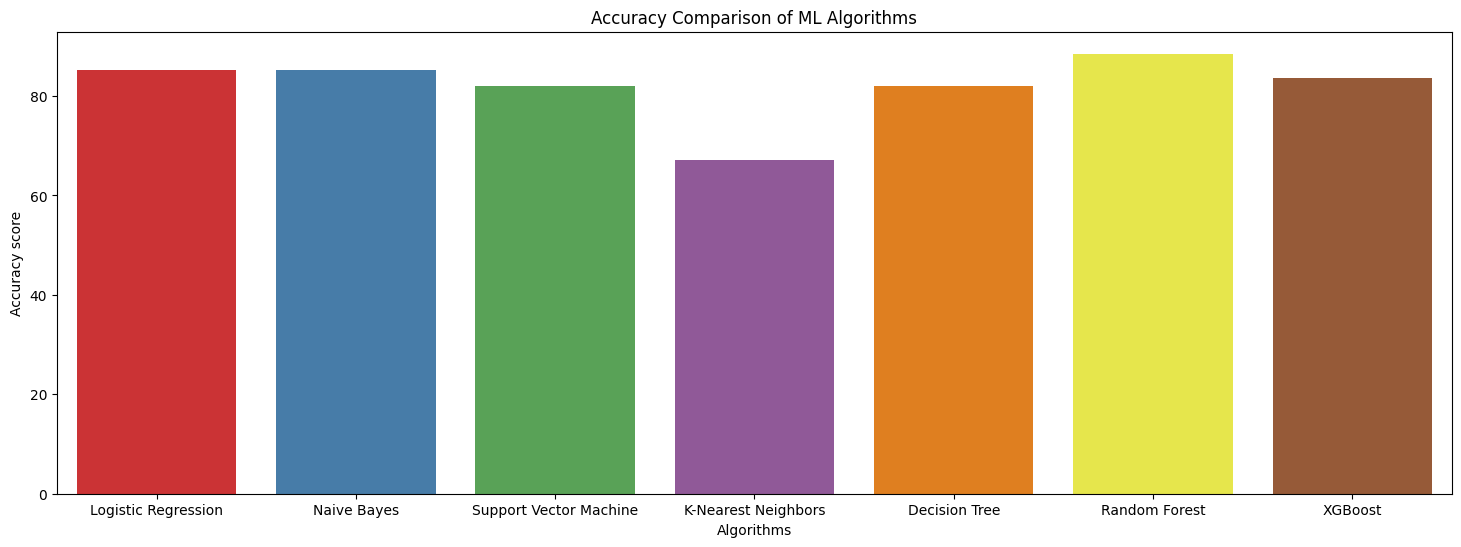

In [67]:
df = pd.DataFrame({
    "algorithms": algorithms,
    "scores": scores
})
plt.figure(figsize=(18,6))
plt.xlabel("Algorithms")
plt.ylabel("Accuracy score")
sns.barplot(x="algorithms", y="scores", data=df,  hue="algorithms",palette="Set1")
plt.title("Accuracy Comparison of ML Algorithms")
plt.show()

### Here, the random forest has good result as compare to other algorithms <br>

In [68]:
### Save Trained Model

In [69]:
import pickle
import os

# Create 'model' folder if it doesn't exist
os.makedirs("model", exist_ok=True)

# Save the Random Forest model instead of Logistic Regression
with open("model/heartmodel.pkl", "wb") as f:
    pickle.dump(rf, f)

print("✅ Random Forest model saved successfully at: model/heartmodel.pkl")


✅ Random Forest model saved successfully at: model/heartmodel.pkl


In [70]:

model = pickle.load(open('model/heartmodel.pkl', 'rb'))
print(type(model))


<class 'sklearn.ensemble._forest.RandomForestClassifier'>
